AL 40,41,44,47,48,49
GP 40,41,42,46,47,48,49
QBC 40,41,43,45,46
= 40,41

In [2]:
from pathlib import Path
import re

path = Path(r"C:\Users\weiso\Documents\GitHub\ALinSim\results\result_single_trc\GP_idx_51.txt")
lines = path.read_text(encoding="utf-8").splitlines()

results = []
i = 0

while i < len(lines):
    m = re.match(r"^(\d+): X_train und x_test:\s*(.*)$", lines[i])
    if not m:
        i += 1
        continue

    step = int(m.group(1))
    block = [m.group(2)]
    i += 1

    while i < len(lines) and not re.match(r"^Query step:\s*\d+", lines[i]):
        block.append(lines[i])
        i += 1

    block_text = "\n".join(block)

    # 分开 X 和 y 两个数组
    x_part, y_part = block_text.split("]] [[")

    # 把被 split 吃掉的括号补回来
    x_part = x_part + "]]"
    y_part = "[[" + y_part

    # 统计每一行 array row
    x_rows = re.findall(r"\[[0-9\s]+\]", x_part)
    y_rows = re.findall(r"\[[0-9.eE+\-\s]+\]", y_part)

    results.append((step, len(x_rows), len(y_rows)))

for step, x_count, y_count in results:
    print(f"step {step}: X rows = {x_count}, y rows = {y_count}")


step 0: X rows = 5, y rows = 5
step 1: X rows = 10, y rows = 10
step 2: X rows = 15, y rows = 15
step 3: X rows = 20, y rows = 20
step 4: X rows = 25, y rows = 25
step 5: X rows = 30, y rows = 30
step 6: X rows = 35, y rows = 35
step 7: X rows = 40, y rows = 40
step 8: X rows = 45, y rows = 45
step 9: X rows = 50, y rows = 50
step 10: X rows = 55, y rows = 55
step 11: X rows = 60, y rows = 60
step 12: X rows = 65, y rows = 65
step 13: X rows = 70, y rows = 70
step 14: X rows = 75, y rows = 75
step 15: X rows = 80, y rows = 80
step 16: X rows = 85, y rows = 85
step 17: X rows = 90, y rows = 90
step 18: X rows = 95, y rows = 95
step 19: X rows = 100, y rows = 100
step 20: X rows = 105, y rows = 105


In [3]:
import json
from pathlib import Path

import pandas as pd

base_dir = Path(r"C:\Users\weiso\Documents\GitHub\ALinSim\results\result_single_trc\result_trc_auto")

rows = []

for seed in [40, 41, 42, 43, 44, 46, 47, 49, 50, 51]:
    for idx in range(21):  # 00-20
        suffix = f"{idx:02d}"
        file_path = base_dir / f"AM_AL_results_seed_{seed}_{suffix}.json"

        if not file_path.exists():
            print(f"Missing file: {file_path.name}")
            continue

        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        rows.append({
            "seed": seed,
            "run_id": suffix,
            "mae": data.get("mae"),
            "rmse": data.get("rmse"),
            "r2": data.get("r2"),
        })

df = pd.DataFrame(rows)
df = df.sort_values(["seed", "run_id"]).reset_index(drop=True)

output_path = base_dir / f"AutoML_AL_results.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Saved to: {output_path}")
print(df.head())


Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\results\result_single_trc\result_trc_auto\AutoML_AL_results.csv
   seed run_id        mae       rmse        r2
0    40     00  21.465388  34.069059 -0.096996
1    40     01  18.683047  27.222632  0.140423
2    40     02  12.296242  29.813096  0.524728
3    40     03  18.505508  30.840667  0.309698
4    40     04  16.579329  32.353912  0.151362


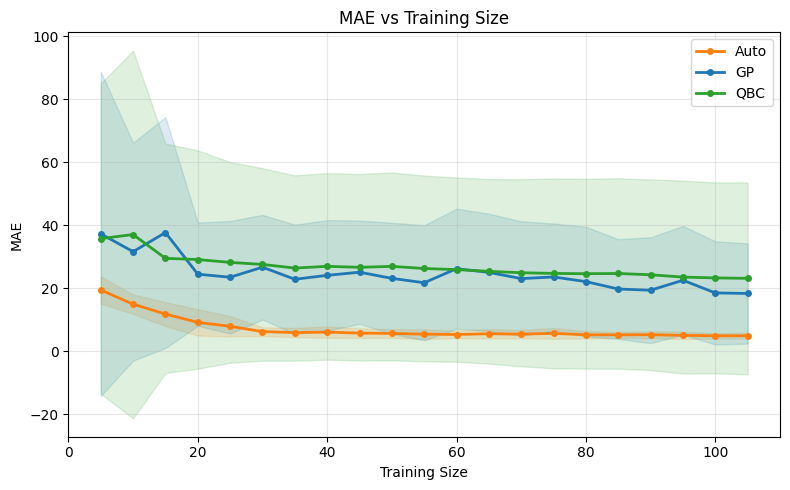

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\mae_clean.png


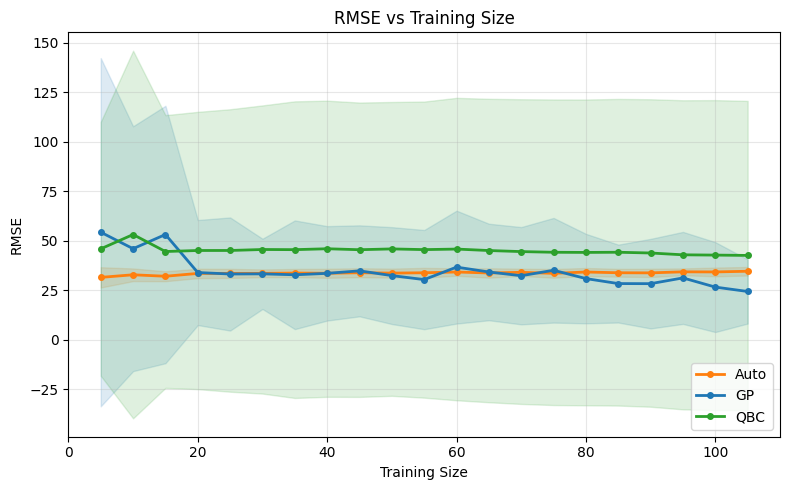

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\rmse_clean.png


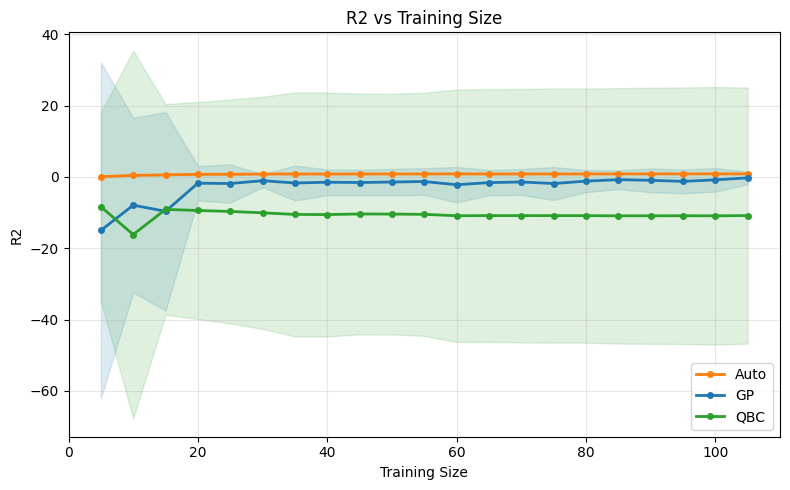

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\r2_clean.png


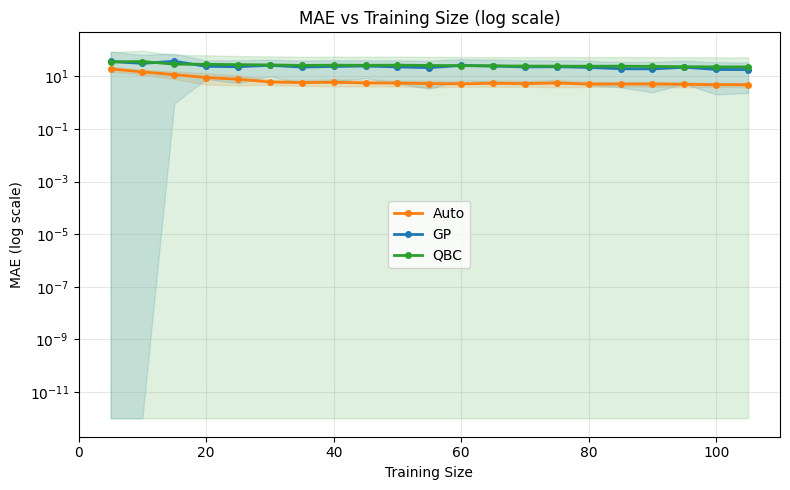

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\mae_log_clean.png


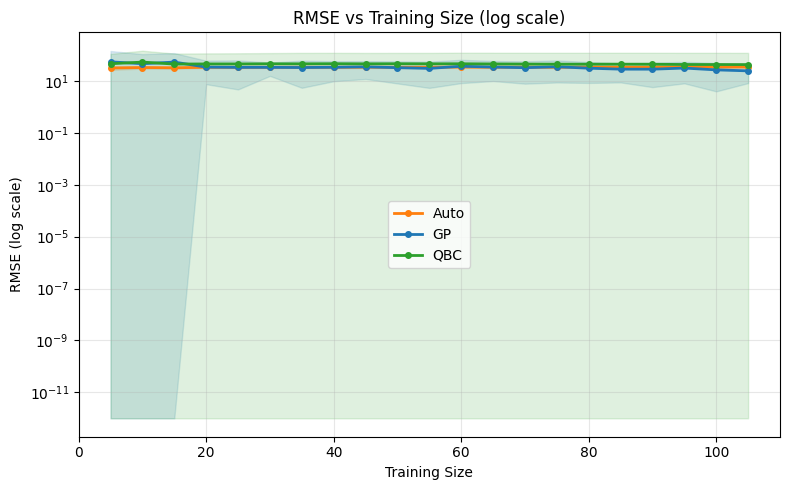

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\rmse_log_clean.png


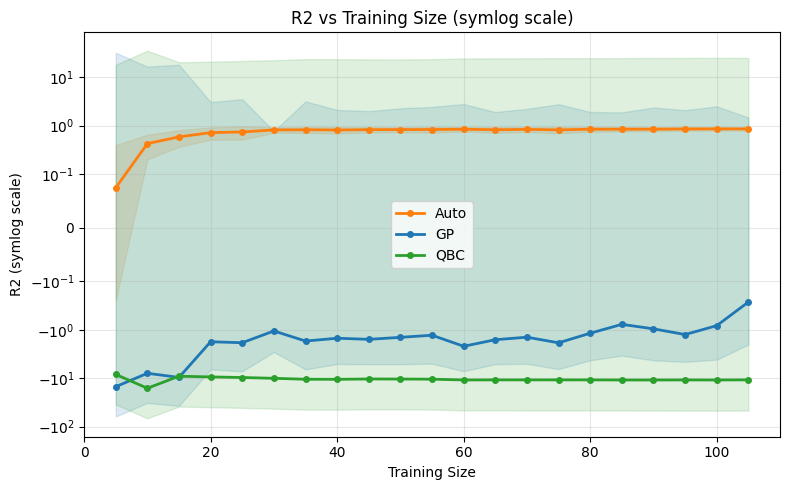

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\r2_log_clean.png


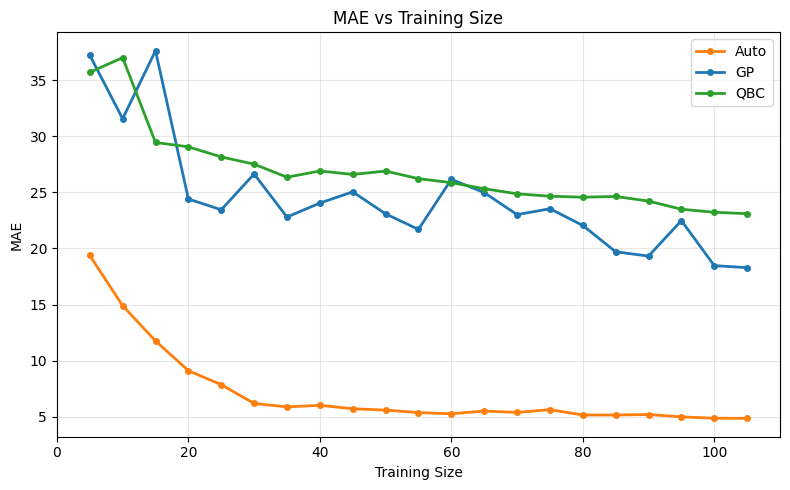

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\mae_no_std_clean.png


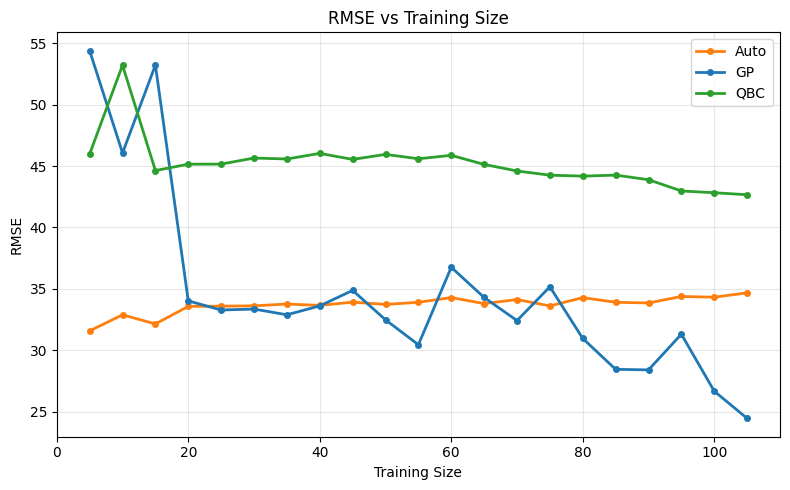

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\rmse_no_std_clean.png


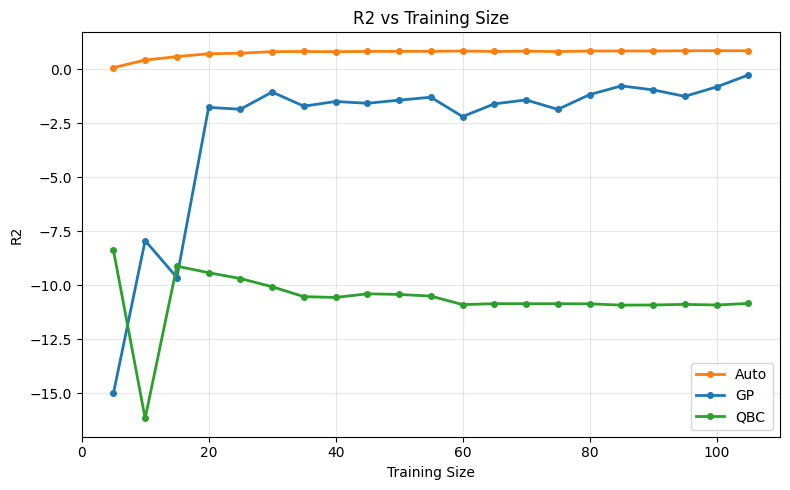

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\r2_no_std_clean.png


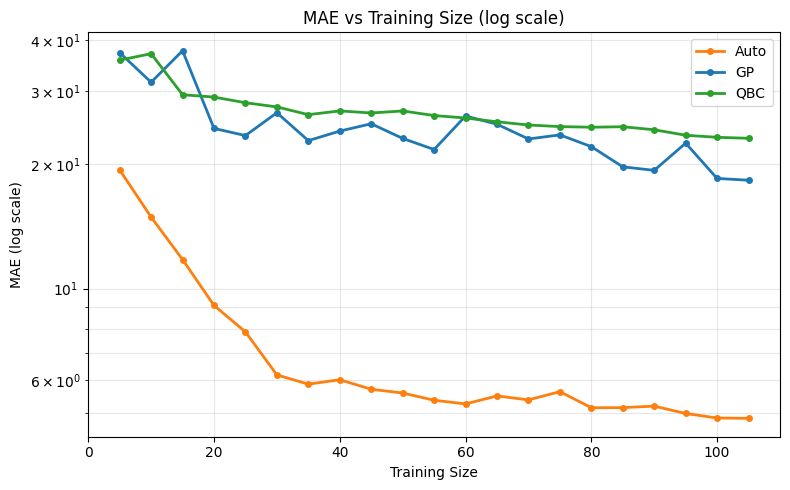

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\mae_no_std_log_clean.png


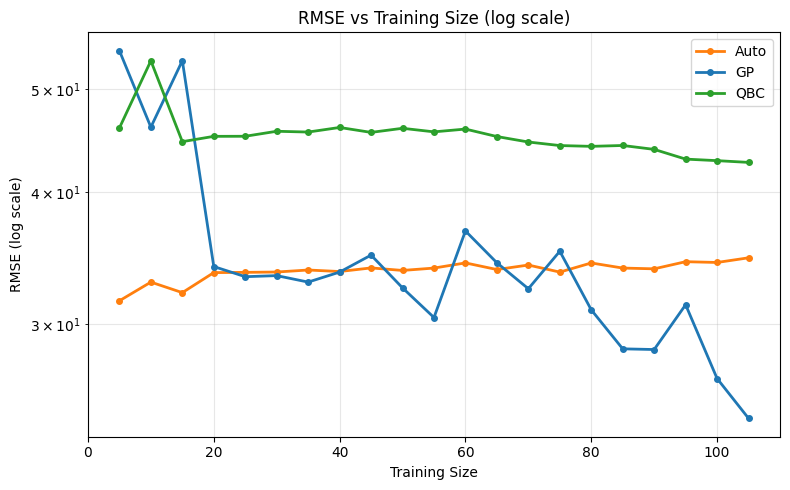

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\rmse_no_std_log_clean.png


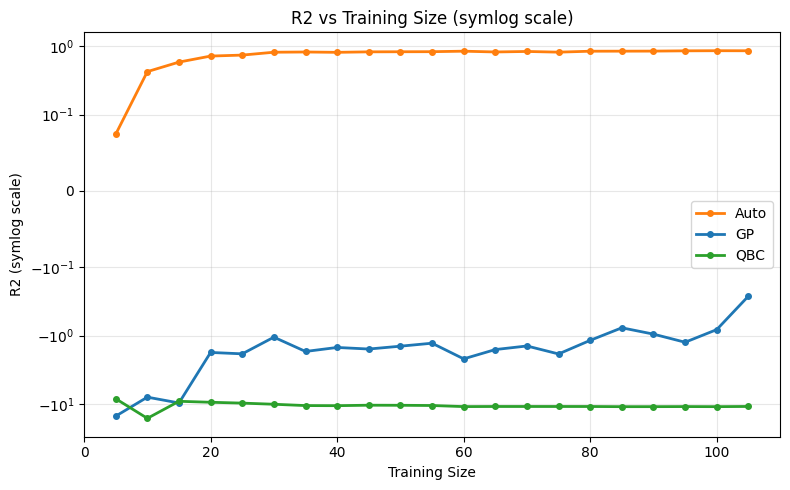

Saved to: C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc\r2_no_std_log_clean.png


In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

base_dir = Path(r"C:\Users\weiso\Documents\GitHub\ALinSim\results\result_single_trc")
auto_csv = base_dir / "result_trc_auto" / "AutoML_AL_results.csv"
output_dir = Path(r"C:\Users\weiso\Documents\GitHub\ALinSim\result_plot\trc")
output_dir.mkdir(parents=True, exist_ok=True)

metrics = ["mae", "rmse", "r2"]
seeds = [40, 41, 42, 43, 44, 46, 47, 49, 50, 51]  # 注意这里不包含 seed 43


def load_json_result(json_path, method_name, seed):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(
        {
            "step": range(len(data["mae"])),
            "mae": data["mae"],
            "rmse": data["rmse"],
            "r2": data["r2"],
        }
    )
    df["method"] = method_name
    df["seed"] = seed
    return df


def load_auto_result(csv_path, seeds):
    df = pd.read_csv(csv_path)

    if "run_id" in df.columns:
        df = df.rename(columns={"run_id": "step"})

    df["step"] = df["step"].astype(int)
    df = df[df["seed"].isin(seeds)].copy()
    df["method"] = "Auto"
    return df[["step", "mae", "rmse", "r2", "method", "seed"]]


def plot_metric(df_stat, metric, log_scale=False, symlog_scale=False, show_std=True):
    plt.figure(figsize=(8, 5))

    for method in method_order:
        sub = df_stat[df_stat["method"] == method].sort_values("train_size")

        x = sub["train_size"]
        y = sub[f"{metric}_mean"]
        y_std = sub[f"{metric}_std"].fillna(0)

        if log_scale:
            valid = y > 0
            x = x[valid]
            y = y[valid]
            y_std = y_std[valid]
            if y.empty:
                continue
            lower = (y - y_std).clip(lower=1e-12)
        else:
            lower = y - y_std

        upper = y + y_std

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            markersize=4,
            label=method,
            color=colors[method],
        )
        if show_std:
            plt.fill_between(x, lower, upper, color=colors[method], alpha=0.15)

    plt.xlabel("Training Size")
    scale_label = "log scale" if log_scale else "symlog scale" if symlog_scale else None
    plt.ylabel(f"{metric.upper()} ({scale_label})" if scale_label else metric.upper())
    plt.title(
        f"{metric.upper()} vs Training Size (log scale)"
        if log_scale
        else f"{metric.upper()} vs Training Size (symlog scale)"
        if symlog_scale
        else f"{metric.upper()} vs Training Size"
    )
    if log_scale:
        plt.yscale("log")
    elif symlog_scale:
        plt.yscale("symlog", linthresh=0.1)
    plt.legend()
    plt.grid(True, alpha=0.3, which="both")
    plt.tight_layout()

    suffix = "_log" if (log_scale or symlog_scale) else ""
    if not show_std:
        suffix = f"_no_std{suffix}"
    save_path = output_dir / f"{metric}{suffix}_clean.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved to: {save_path}")


frames = [load_auto_result(auto_csv, seeds)]

for seed in seeds:
    gp_path = base_dir / f"GP_AL_results_seed_{seed}.json"
    qbc_path = base_dir / f"QBC_AL_PAN_results_seed_{seed}.json"

    frames.append(load_json_result(gp_path, "GP", seed))
    frames.append(load_json_result(qbc_path, "QBC", seed))

df_all = pd.concat(frames, ignore_index=True)
df_all["train_size"] = (df_all["step"] + 1) * 5

df_stat = (
    df_all.groupby(["method", "step", "train_size"])[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

df_stat.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in df_stat.columns
]

method_order = ["Auto", "GP", "QBC"]
colors = {
    "GP": "tab:blue",
    "Auto": "tab:orange",
    "QBC": "tab:green",
}

for metric in metrics:
    plot_metric(df_stat, metric, log_scale=False, show_std=True)

for metric in ["mae", "rmse"]:
    plot_metric(df_stat, metric, log_scale=True, show_std=True)

plot_metric(df_stat, "r2", symlog_scale=True, show_std=True)

for metric in metrics:
    plot_metric(df_stat, metric, log_scale=False, show_std=False)

for metric in ["mae", "rmse"]:
    plot_metric(df_stat, metric, log_scale=True, show_std=False)

plot_metric(df_stat, "r2", symlog_scale=True, show_std=False)
